In [16]:
import os
import json
import torch
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from transformers import AutoImageProcessor, AutoModelForImageClassification
from dotenv import load_dotenv
from pathlib import Path

load_dotenv()
PROJECT_ROOT = Path.cwd().parent
model_dir = PROJECT_ROOT / os.environ.get("MODEL_DIR", "models/final_model")

processor = AutoImageProcessor.from_pretrained(str(model_dir))
model = AutoModelForImageClassification.from_pretrained(str(model_dir))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

BeitForImageClassification(
  (beit): BeitModel(
    (embeddings): BeitEmbeddings(
      (patch_embeddings): BeitPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): BeitEncoder(
      (layer): ModuleList(
        (0): BeitLayer(
          (attention): BeitAttention(
            (attention): BeitSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): BeitSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): BeitIntermediate(
            (dense): Linear(in_fe

In [17]:
checkpoint_dir = PROJECT_ROOT / os.environ.get("CHECKPOINT_DIR", "models/checkpoints")
state_path = None

if checkpoint_dir.exists():
    checkpoints = [d for d in checkpoint_dir.iterdir() if d.is_dir() and d.name.startswith("checkpoint")]
    if checkpoints:
        latest_checkpoint = max(checkpoints, key=lambda d: d.stat().st_mtime)
        state_path = latest_checkpoint / "trainer_state.json"

if state_path and state_path.exists():
    with open(state_path, "r") as f:
        trainer_state = json.load(f)

    eval_log = next((log for log in reversed(trainer_state.get("log_history", [])) if "eval_accuracy" in log), {})

    if eval_log:
        metrics_data = {
            "Parameter": ["Best Metric", "Global Steps", "Final Eval Accuracy", "Final Eval Loss", "Epochs Completed"],
            "Value": [
                trainer_state.get("best_metric", "N/A"),
                trainer_state.get("global_step", "N/A"),
                f"{eval_log.get('eval_accuracy', 0):.4f}",
                f"{eval_log.get('eval_loss', 0):.4f}",
                f"{eval_log.get('epoch', 0):.2f}"
            ]
        }

        df = pd.DataFrame(metrics_data)
        styled_df = df.style.hide(axis="index").set_caption("Extracted Training Configuration and Metrics")

        display(styled_df)
    else:
        print("No evaluation metrics found in log history.")
else:
    print("trainer_state.json not found. Model must be evaluated manually.")

Parameter,Value
Best Metric,0.810000
Global Steps,1350
Final Eval Accuracy,0.8100
Final Eval Loss,0.6997
Epochs Completed,3.00


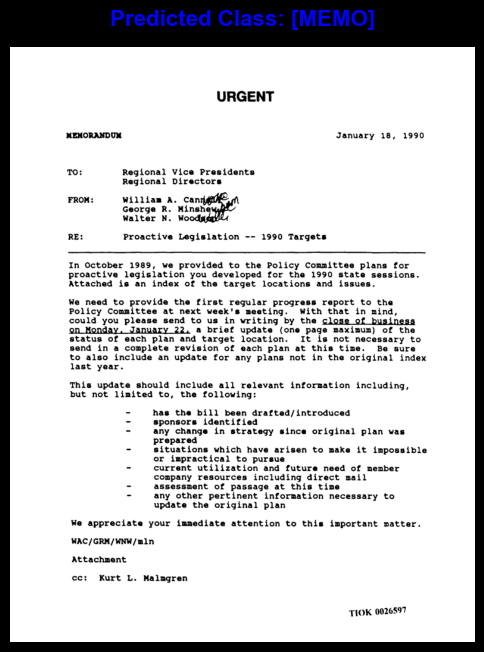

In [18]:
raw_data_dir = PROJECT_ROOT / os.environ.get("RAW_DATA_DIR", "data/raw")
image_path = raw_data_dir / "memo" / "00001825.tif"

if image_path.exists():
    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        predicted_class_id = outputs.logits.argmax(-1).item()

    predicted_label = model.config.id2label[predicted_class_id]

    fig, ax = plt.subplots(figsize=(6, 8))
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f"Predicted Class: [{predicted_label.upper()}]",
                 fontsize=16, fontweight='bold', color='blue', pad=15)
    plt.show()
else:
    print(f"File not found: {image_path}")